# Spin spirals, without a supercell

A flat spiral turns the moment by $\mathbf q\cdot\mathbf R$ from one cell to the next, so it
is periodic only when $\mathbf q$ is commensurate, and a supercell large enough for a general
wavevector is out of reach. The generalized Bloch theorem removes the need: the spiral is a
*gauge*, and in the rotated frame the density and the potential are lattice periodic again.

$$\psi_{n\mathbf k}(\mathbf r) = e^{i\mathbf k\cdot\mathbf r}
  \begin{pmatrix}
    e^{-i\mathbf q\cdot\mathbf r/2}\; u^{\uparrow}_{n\mathbf k}(\mathbf r) \\[3pt]
    e^{+i\mathbf q\cdot\mathbf r/2}\; u^{\downarrow}_{n\mathbf k}(\mathbf r)
  \end{pmatrix}
\qquad\Longrightarrow\qquad
\uparrow \text{ at } \mathbf k + \tfrac{\mathbf q}{2},
\quad
\downarrow \text{ at } \mathbf k - \tfrac{\mathbf q}{2}$$

The up component of the spinor lives at $\mathbf k + \mathbf q/2$ and the down at
$\mathbf k - \mathbf q/2$, each on its own plane-wave sphere. **Any** wavevector in the zone
is then a one-cell calculation, which is what makes a magnon dispersion affordable at all.

`pw.x` has no spin spiral, so the validation is a set of limits: at the wavevectors where a
supercell *is* possible, the spiral has to reproduce it, and it does --

| limit | what it must equal | agreement |
|---|---|---|
| $q = 0$ | an ordinary noncollinear run | 1e-12 Ry |
| $q = b_3/2$ | the collinear antiferromagnet of a doubled cell | 1e-12 Ry |
| $q = b_3/4$ | a four-cell 90-degree noncollinear supercell | 1e-12 Ry |

with only the *electronic* energy compared for the last two, since the Ewald sum of a
one-atom cell and of its supercell are genuinely different numbers and agree per atom anyway.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from pypresso import Calculator

PSEUDO, CASES = Path("../tests/data/pseudo"), Path("../tests/data/qe")
CHAIN = (CASES / "h-chain-spiral.in").read_text()

chain = Calculator.from_text(CHAIN, PSEUDO, announce=False, max_iterations=200)
scf = chain.get_scf()
print("hydrogen chain at q = %s:   E = %.9f Ry,   |m| = %.4f mu_B"
      % (chain.system.spiral_q, scf.total_energy,
         np.linalg.norm(scf.magnetization_vector)))

hydrogen chain at q = (0.0, 0.0, 0.25):   E = -0.954746110 Ry,   |m| = 0.5396 mu_B


One atom per cell, a chain along $z$, and a quarter-turn spiral. In the *rotated* frame this
is an ordinary self-consistent run: the density is lattice periodic, the mixer and the
functional are untouched, and the whole of the implementation is that the two spinor
components sit on two different spheres.

## `E(q)`: the frozen-magnon dispersion

Scanning $\mathbf q$ costs one self-consistent run per point and no supercell at all, which
is the whole reason the theorem is worth having. Where the curve falls away from $q = 0$ the
chain prefers to twist, and fitting a Heisenberg model to it gives the exchange constants a
spin model would be built from.

all 11 points converged: True


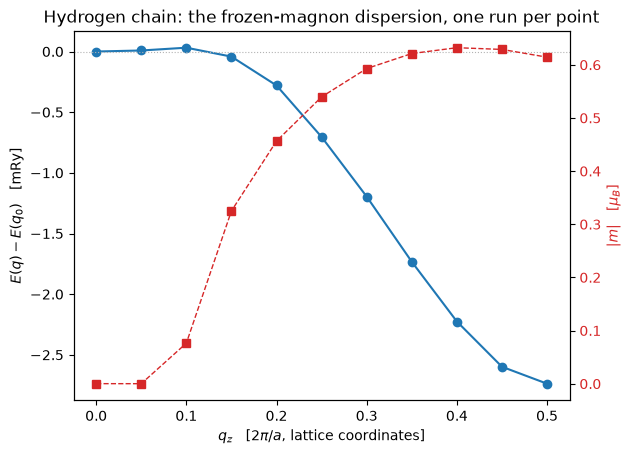

In [2]:
scan = chain.get_spiral_scan([[0.0, 0.0, q] for q in np.linspace(0.0, 0.5, 11)],
                             max_iterations=200)

ax = scan.plot()
ax.set_title("Hydrogen chain: the frozen-magnon dispersion, one run per point")
print("all %d points converged: %s" % (len(scan.energies), bool(np.all(scan.converged))))

The curve falls away from $q = 0$ all the way to the zone boundary, so the ground state of
this chain is the antiferromagnet at $q = b_3/2$ -- which is what notebook 14 relaxes to
without being told.

**The moment does not merely change along it, it collapses.** Below $q \approx 0.15$ the
chain has no moment at all: a slow spiral costs the two channels less than polarising them
gains, so the self-consistent solution is the non-magnetic one and $E(q)$ is flat there. A
Heisenberg model has nothing to describe on that stretch, which is why the fit divides by
$|m|^2$ rather than assuming a fixed spin length, and why the two-shell residual is 2% rather
than nothing.

In [3]:
from pypresso.workflows.spiral import heisenberg_exchange   # no facade route to a fit

RY_TO_MEV = 13605.693122994
SHELLS = [[0.0, 0.0, 1.0], [0.0, 0.0, 2.0]]        # nearest and next-nearest neighbours

q = scan.wavevectors[:, 2]
J = heisenberg_exchange(scan, chain.system.cell, SHELLS)
model = sum(J[n] * (1.0 - np.cos(2.0 * np.pi * q * (n + 1))) for n in range(len(SHELLS)))
model = model * np.mean(np.linalg.norm(scan.moments, axis=1)) ** 2
residual = np.max(np.abs(model - (scan.energies - scan.energies[0])))

print("J1 = %+.3f meV  (nearest)      J2 = %+.3f meV  (next-nearest)"
      % (J[0] * RY_TO_MEV, J[1] * RY_TO_MEV))
print("largest residual of the two-shell fit   %.3f meV   (%.1f%% of the curve)"
      % (residual * RY_TO_MEV,
         100 * residual / max(abs(scan.energies - scan.energies[0]))))

J1 = -112.256 meV  (nearest)      J2 = +28.989 meV  (next-nearest)
largest residual of the two-shell fit   0.814 meV   (2.2% of the curve)


A negative $J_1$ is antiferromagnetic in the convention
$H = -\sum J_{ij}\,\mathbf e_i\cdot\mathbf e_j$, which is what a curve falling away from
$q = 0$ has to give. Two shells already capture the curve; a third would be measuring the
sampling error rather than the physics.

**The moment is a gauge and the energy is not.** Running at $\mathbf q$ and at
$\mathbf q + \mathbf b_3$ gives the same energy and a *different* cell-integrated moment: the
rotated frame is a choice, and only frame-independent quantities are physical.

## What it refuses

**Spin-orbit coupling, permanently** -- it ties the spin to the lattice and breaks the
theorem outright, and Elk refuses the combination for the same reason. **Symmetry**, until
the spin space group is written, so a spiral runs `nosym` on the full k-grid. And
**ultrasoft or PAW datasets**, until the augmentation charge *between the two components* is
threaded through -- that is $q_{ij}(\mathbf q)$ and not the ordinary $q_{ij}$, a different
object that the two-sphere structure is exactly what makes necessary.

---
Notebook 14 relaxes $\mathbf q$ itself downhill, which costs a fraction of the runs this scan
does. The tests behind this notebook: `tests/regression/test_spin_spirals.py`, which holds
the three limits of the table above, the gauge invariance of the energy under
$\mathbf q \to \mathbf q + \mathbf b$, and the two-sphere basis construction.